In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.pandas.set_option("display.max_columns", None)

# Create dataframe
df = pd.read_csv(r"EasyVisa.csv")
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [45]:
# features with na

features_with_na = [col for col in df.columns if df[col].isna().sum() >= 1]
print(features_with_na)

[]


In [46]:
# duplicated row

df.duplicated().sum().item()

0

In [47]:
# remove case id

df.drop(columns=['case_id'], inplace=True)
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [48]:
# importing date class from datetime module

from datetime import date

# creating data obj of today's date
today_date = date.today()
current_year = today_date.year
current_year

2026

In [49]:
df['comany_age'] = current_year - df['yr_of_estab']
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,comany_age
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,19
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,24
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,18
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,129
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,21


In [50]:
df.drop(columns=['yr_of_estab'], inplace=True)
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,comany_age
0,Asia,High School,N,N,14513,West,592.2029,Hour,Y,Denied,19
1,Asia,Master's,Y,N,2412,Northeast,83425.6500,Year,Y,Certified,24
2,Asia,Bachelor's,N,Y,44444,West,122996.8600,Year,Y,Denied,18
3,Asia,Bachelor's,N,N,98,West,83434.0300,Year,Y,Denied,129
4,Africa,Master's,Y,N,1082,South,149907.3900,Year,Y,Certified,21


In [51]:
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print(f"len of cat cols: {len(cat_features)} & len of num cols: {len(num_features)}")

len of cat cols: 8 & len of num cols: 3


In [52]:
cat_features

['continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

In [53]:
discrete_features = [col for col in df.columns if df[col].nunique() <= 25]
continuous_features = [col for col in df.columns if df[col].nunique() > 25]

continuous_features


['no_of_employees', 'prevailing_wage', 'comany_age']

In [54]:
discrete_features

['continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

In [152]:
X = df.drop(columns=['case_status'])
y = df['case_status']

y

0           Denied
1        Certified
2           Denied
3           Denied
4        Certified
           ...    
25475    Certified
25476    Certified
25477    Certified
25478    Certified
25479    Certified
Name: case_status, Length: 25480, dtype: object

In [153]:
y = np.where(y == 'Denied', 1, 0)
y

array([1, 0, 1, ..., 0, 0, 0], shape=(25480,))

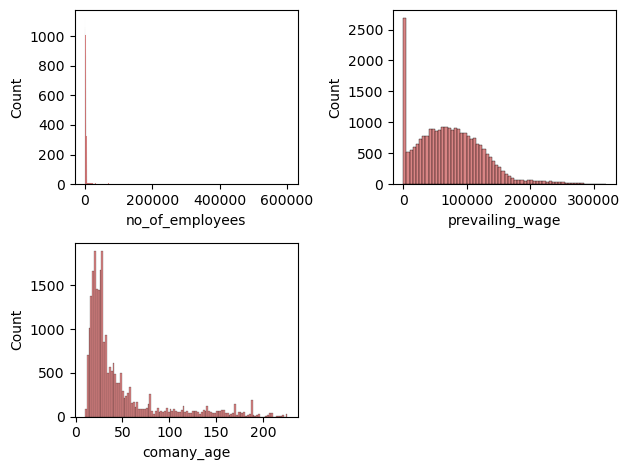

In [57]:
# feature transformation
for i, col in enumerate(continuous_features):
    plt.subplot(2, 2, i+1)
    sns.histplot(x=X[col], color='indianred')
    plt.xlabel(col)
    plt.tight_layout()
plt.show()

In [58]:
# checking for skewness

df[continuous_features].skew(axis=0, skipna=True)

no_of_employees    12.265260
prevailing_wage     0.755776
comany_age          2.037301
dtype: float64

In [59]:
# we apply power transformation to see if it reduces the skewness

from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
transform_features = ['no_of_employees', 'comany_age']
X_copy = pt.fit_transform(X[transform_features])

In [60]:
X_copy = pd.DataFrame(X_copy, columns=transform_features)
X_copy

,no_of_employees,comany_age
0,1.517300,-0.958506
1,0.030912,-0.470816
2,2.885076,-1.080479
3,-1.343550,1.632700
4,-0.432287,-0.741917
...,...,...
25475,0.079917,-1.080479
25476,0.235747,-0.846032
25477,-0.413885,1.552921
25478,-0.111949,1.685772


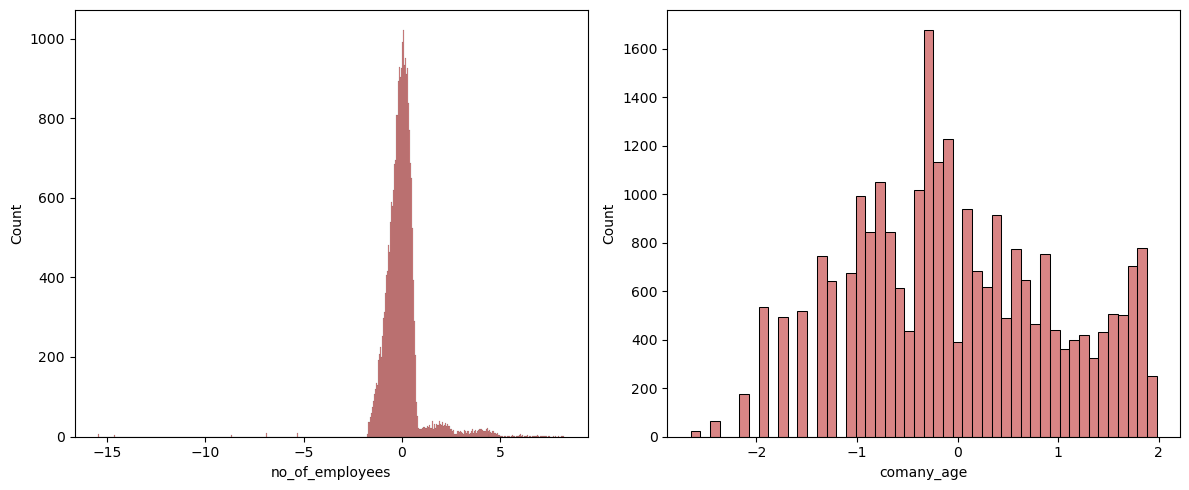

In [61]:
plt.figure(figsize=(12, 5))
for i, col in enumerate(transform_features):
    plt.subplot(1, 2, i+1)
    sns.histplot(x=X_copy[col], color='indianred')
    plt.xlabel(col)
    plt.tight_layout()
plt.show()

In [62]:
# checking the skewness again 

X_copy.skew(axis=0, skipna=True)

no_of_employees    0.399339
comany_age         0.120823
dtype: float64

In [63]:
X.education_of_employee.unique()

array(['High School', "Master's", "Bachelor's", 'Doctorate'], dtype=object)

In [74]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [67]:
df[num_features].skew()

no_of_employees    12.265260
prevailing_wage     0.755776
comany_age          2.037301
dtype: float64

In [143]:
# Create Column Transformer with 3 types of transformers

# Column groups
ordinal_columns = ['education_of_employee']

onehot_columns = [
    'continent',
    'region_of_employment',
    'unit_of_wage',
    'has_job_experience',
    'requires_job_training',
    'full_time_position'
]

skewed_columns = ['no_of_employees', 'comany_age']
normal_columns = ['prevailing_wage']

# Correct order
education_hierarchy = [['High School', "Bachelor's", "Master's", 'Doctorate']]

preprocessor = ColumnTransformer(
    [
        ("onehot", OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_columns),
        ("ordinal", OrdinalEncoder(categories=education_hierarchy), ordinal_columns),
        ("power", PowerTransformer(method='yeo-johnson'), skewed_columns),
        ("scaler", StandardScaler(), normal_columns)
    ],
    verbose_feature_names_out=False
)

preprocessor.set_output(transform='pandas')


,transformers,"[('onehot', ...), ('ordinal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,False


In [154]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, stratify=y, random_state=100)

type(X_train)

pandas.core.frame.DataFrame

In [136]:
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.pipeline import pipeline

# X = preprocessor.fit_transform(X)


# # resampling the minority class
# smt = SMOTEENN(random_state=100, sampling_strategy='minority')
# # fit the model to generate data
# X_res, y_res = smt.fit_resample(X, y)


In [137]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from imblearn.pipeline import Pipeline

In [156]:
def evaluate_clf(true, pred):
    return {
        "accuracy": accuracy_score(true, pred),
        "f1_score": f1_score(true, pred),
        "precision": precision_score(true, pred),
        "recall": recall_score(true, pred),
        "roc_auc": roc_auc_score(true, pred)
    }

In [139]:
models = {
    "RandomForestClassifier": RandomForestClassifier(),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "GradientBoostingClassifier": GradientBoostingClassifier(),
    "LogisticRegression": LogisticRegression(),
    "KNeighborsClassifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "CatBoostClassifier": CatBoostClassifier(verbose=0),
    "Support Vector Classifier": SVC(probability=True),
    "AdaBoostClassifier": AdaBoostClassifier()
}

In [140]:
list(models.values())[0]

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [157]:
# create a function which evaluates models and return a report

def evaluate_models(data, models):
    
    X_train, X_test, y_train, y_test = data

    models_list = []
    accuracey_list = []
    roc_list = []


    for model_name, model in models.items():
        # create a pipe for each model
        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("resampler", SMOTETomek(random_state=100)),
            ("model", model)
        ])

        pipe.fit(X_train, y_train)

        # generating predictions
        y_train_pred = pipe.predict(X_train)
        y_test_pred = pipe.predict(X_test)

        # train set performance
        train_metrics = evaluate_clf(
            y_train,
            y_train_pred
        )

        # test set performance
        test_metrics = evaluate_clf(
            y_test,
            y_test_pred
        )

        print(f"{model_name} Model Performance for Training Set")
        print(f"- Accuracy: {train_metrics['accuracy']:.4f}")
        print(f"- F1 Score: {train_metrics['f1_score']:.4f}")
        print(f"- Precision: {train_metrics['precision']:.4f}")
        print(f"- Recall: {train_metrics['recall']:.4f}")
        print(f"- Roc Auc Score: {train_metrics['roc_auc']:.4f}")

        print("------------------------------------")

        print(f"{model_name} Model Performance for Test Set")
        print(f"- Accuracy: {test_metrics['accuracy']:.4f}")
        print(f"- F1 Score: {test_metrics['f1_score']:.4f}")
        print(f"- Precision: {test_metrics['precision']:.4f}")
        print(f"- Recall: {test_metrics['recall']:.4f}")
        print(f"- Roc Auc Score: {test_metrics['roc_auc']:.4f}")

        accuracey_list.append(test_metrics['accuracy'])
        roc_list.append(test_metrics['roc_auc'])

        print("=" * 35)
        print("\n")

    report = pd.DataFrame(
        list(zip(list(models.keys()), accuracey_list, roc_list)), 
        columns=["Model Name", "Accuracy", "ROC"]
    )
    
    return report

In [158]:
base_model = evaluate_models((X_train, X_test, y_train, y_test), models)

RandomForestClassifier Model Performance for Training Set
- Accuracy: 0.9504
- F1 Score: 0.9252
- Precision: 0.9262
- Recall: 0.9242
- Roc Auc Score: 0.9438
------------------------------------
RandomForestClassifier Model Performance for Test Set
- Accuracy: 0.7210
- F1 Score: 0.5795
- Precision: 0.5801
- Recall: 0.5790
- Roc Auc Score: 0.6853


DecisionTreeClassifier Model Performance for Training Set
- Accuracy: 0.9509
- F1 Score: 0.9261
- Precision: 0.9253
- Recall: 0.9269
- Roc Auc Score: 0.9449
------------------------------------
DecisionTreeClassifier Model Performance for Test Set
- Accuracy: 0.6608
- F1 Score: 0.5233
- Precision: 0.4907
- Recall: 0.5605
- Roc Auc Score: 0.6356


GradientBoostingClassifier Model Performance for Training Set
- Accuracy: 0.7229
- F1 Score: 0.6135
- Precision: 0.5715
- Recall: 0.6622
- Roc Auc Score: 0.7076
------------------------------------
GradientBoostingClassifier Model Performance for Test Set
- Accuracy: 0.7295
- F1 Score: 0.6208
- Precis

In [159]:
base_model

,Model Name,Accuracy,ROC
0,RandomForestClassifier,0.720958,0.685272
1,DecisionTreeClassifier,0.660780,0.635566
2,GradientBoostingClassifier,0.729461,0.713712
3,LogisticRegression,0.685505,0.696740
4,KNeighborsClassifier,0.671769,0.669233
5,XGBClassifier,0.730377,0.695690
6,CatBoostClassifier,0.745160,0.702303
7,Support Vector Classifier,0.732470,0.715074
8,AdaBoostClassifier,0.698980,0.695346


In [165]:
# top 3 models hyper params tuning
xgboost_params = {
    'model__max_depth': range(3, 10, 2),
    'model__min_child_weight': range(1, 6, 2)
}

rf_params = {
    "model__max_depth": [10, 12, None, 15, 20],
    "model__max_features": ['sqrt', 'log2', None],
    "model__n_estimators": [10, 50, 100, 200]
}

knn_params = {
    "model__algorithm": ['auto', 'ball_tree', 'kd_tree', 'brute'],
    "model__weights": ['uniform', 'distance'],
    "model__n_neighbors": [3, 4, 5, 7, 9]
}

In [166]:
# model list for hyper param tuning

randomcv_models = [
    ('XGBoost', XGBClassifier(), xgboost_params),
    ('RF', RandomForestClassifier(), rf_params),
    ('KNN', KNeighborsClassifier(), knn_params)
]

In [167]:
type(X_train)

pandas.core.frame.DataFrame

In [169]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("resampler", SMOTETomek(random_state=100)),
        ("model", model)
    ])

    random = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=params,
        n_iter=100,
        cv=3,
        verbose=2,
        n_jobs=-1
    )

    random.fit(X_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"------------------------ Best params for {model_name} -------------------")
    print(model_param[model_name])
    

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Fitting 3 folds for each of 40 candidates, totalling 120 fits
------------------------ Best params for XGBoost -------------------
{'model__min_child_weight': 3, 'model__max_depth': 5}
------------------------ Best params for RF -------------------
{'model__n_estimators': 200, 'model__max_features': 'sqrt', 'model__max_depth': 12}
------------------------ Best params for KNN -------------------
{'model__weights': 'uniform', 'model__n_neighbors': 4, 'model__algorithm': 'auto'}


In [177]:
# retraining the model

from sklearn.metrics import roc_auc_score

best_models = {
    "RandomForestClassifier", RandomForestClassifier(**model_param['RF']),
    "KNeighborsClassifier", KNeighborsClassifier(**model_param['KNN']),
    "XGBClassifier", XGBClassifier(**model_param['XGBoost'])
}

tuned_report = evaluate_models((X_train, X_test, y_train, y_test), models=best_models)

TypeError: RandomForestClassifier.__init__() got an unexpected keyword argument 'model__n_estimators'

In [173]:
best_model = KNeighborsClassifier(**model_param['knn_params'])
best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("resampler", SMOTETomek(random_state=100)),
    ("model", best_model)
])

y_pred = best_model.predict(X_test)
score = accuracy_score(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print("FINAL MODEL 'kNN'")
print(f"Accuracy Score Value: {score:.4f}")
print(cr)

KeyError: 'knn_params'

In [ ]:
from sklearn import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.show()